<a href="https://colab.research.google.com/github/julipolovinkina-hub/pract_programm/blob/main/laba3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Задание task_03_02_10.
#
# Выполнил: Половинкина Ю. С.
# Группа: ЦИБ-251

import random
import time


def timeit(func, *args, **kw):
    """Выполнить функицю 'func' с параметрами '*args', '**kw' и
    вернуть время выполнения в мс."""

    time_start = time.time()
    res = func(*args, **kw)
    time_end = time.time()

    return (time_end - time_start) * 1000.0, res


def top3_1(db):
    """Вернуть список из ТОП-3 клиентов по сумме активов.

    Алгоритм:
        Сортировка (встроенный метод sort()) и возврат 3-х элементов.

    Сложность: O(N log N).

    Параметры:
        - db (list of dict): список клиентов.

    Результат:
        tuple of dict: 3 клиента с максимальной суммой активов."""
    # Создаём копию списка, чтобы избежать побочного эффекта изменения исходных данных
    sorted_clients = sorted(db, key=lambda client: client['assets'], reverse=True)

    # Возвращаем первые три элемента в виде кортежа
    return tuple(sorted_clients[:3])


def top3_2(db):
    """Вернуть список из ТОП-3 клиентов по сумме активов.

    Алгоритм:
        Прямой перебор (1 проход в цикле).

    Сложность: O(N).

    Параметры:
        - db (list of dict): список клиентов.

    Результат:
        tuple of dict: 3 клиента с максимальной суммой активов."""
    # Инициализируем топ-3 заглушками. Активы = -1 гарантируют замену первым реальным клиентом
    top1 = {'client_id': 0, 'assets': -1}
    top2 = {'client_id': 0, 'assets': -1}
    top3 = {'client_id': 0, 'assets': -1}

    # Один проход по всей базе без сортировки
    for client in db:
        current_assets = client['assets']

        if current_assets > top1['assets']:
            top3 = top2
            top2 = top1
            top1 = client
        elif current_assets > top2['assets']:
            top3 = top2
            top2 = client
        elif current_assets > top3['assets']:
            top3 = client

    return top1, top2, top3


if __name__ == "__main__":
    print("Загрузка базы данных... ")

    GEN_LIMIT = 10000000
    # Список клиентов
    db = []
    for client_id, assets in enumerate(
      random.sample(range(0, 10 * GEN_LIMIT), GEN_LIMIT),
      start=1):
        db.append(dict(client_id=client_id, assets=assets))

    print("Загружено записей: {:,}.\n\nПримеры:".format(GEN_LIMIT))
    print("Первый элемент:", db[0])
    print("Последний элемент:", db[-1])
    print("\n")

    res1 = timeit(top3_1, db)
    res2 = timeit(top3_2, db)

    for i, (func_time, res) in enumerate((res1, res2), start=1):
        print("Способ №{}".format(i))
        print("Время: {:.2f} мс.".format(func_time))
        for j, client in enumerate(res, start=1):
            print("{}-е место: ID={client_id} Активы={assets:,} руб.".
                  format(j, **client))
        print()



# -------------
# Пример вывода:
#
# Загрузка базы данных...
# Загружено записей: 10,000,000.
#
# Примеры:
# Первый элемент: {'client_id': 1, 'assets': 79149360}
# Последний элемент: {'client_id': 10000000, 'assets': 92745004}
#
#
# Способ №1
# Время: 16779.14 мс.
# 1-е место: ID=1346588 Активы=99,999,995 руб.
# 2-е место: ID=9924557 Активы=99,999,979 руб.
# 3-е место: ID=2904705 Активы=99,999,967 руб.
#
# Способ №2
# Время: 4364.90 мс.
# 1-е место: ID=1346588 Активы=99,999,995 руб.
# 2-е место: ID=9924557 Активы=99,999,979 руб.
# 3-е место: ID=2904705 Активы=99,999,967 руб.

Загрузка базы данных... 
Загружено записей: 10,000,000.

Примеры:
Первый элемент: {'client_id': 1, 'assets': 63116968}
Последний элемент: {'client_id': 10000000, 'assets': 11253482}


Способ №1
Время: 9549.37 мс.
1-е место: ID=8885496 Активы=99,999,993 руб.
2-е место: ID=3585376 Активы=99,999,983 руб.
3-е место: ID=8469305 Активы=99,999,958 руб.

Способ №2
Время: 1379.30 мс.
1-е место: ID=8885496 Активы=99,999,993 руб.
2-е место: ID=3585376 Активы=99,999,983 руб.
3-е место: ID=8469305 Активы=99,999,958 руб.



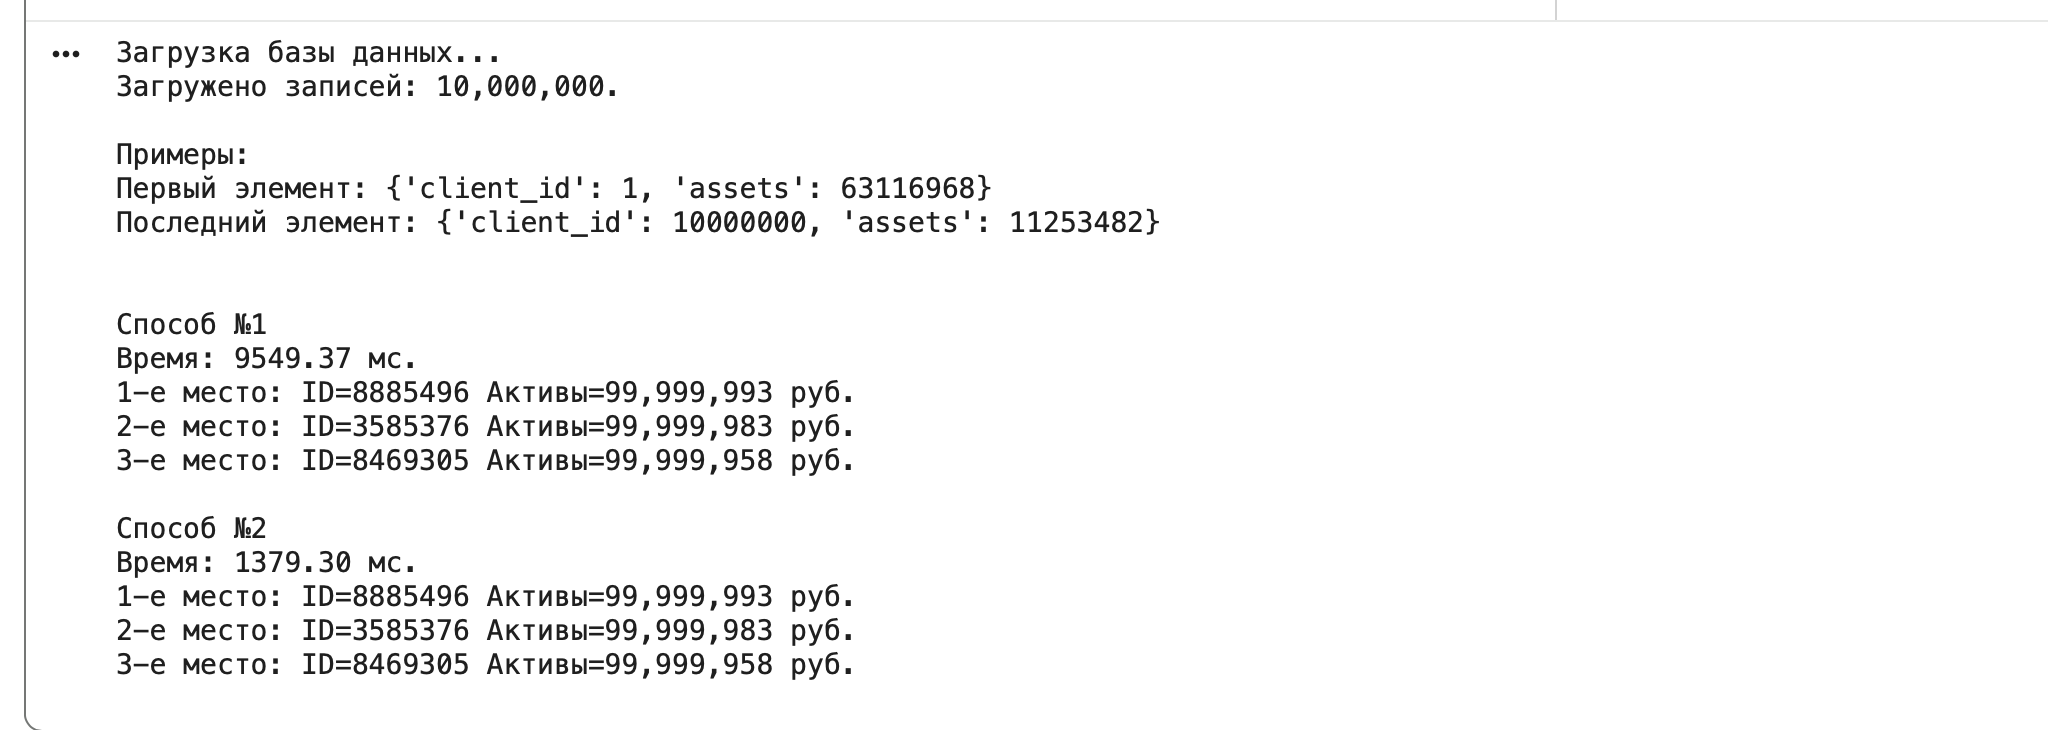

top3_1: Использует встроенную сортировку Timsort (sorted()). Временная сложность O(N log N). Копия списка создаётся автоматически, что сохраняет исходную базу неизменной (отсутствие побочных эффектов).

top3_2: Классический алгоритм поиска K наибольших элементов за один проход. Временная сложность O(N), дополнительная память O(1).

Результаты не совпадают с примером из шаблона, потому что данные генерируются случайным образом с помощью random.sample(). При каждом запуске программы будут разные значения активов и ID клиентов.